# 🔥 GradCAM Visualization with ResNet18 — No Hooks Needed

> Understand *what* your model sees — without a single hook.

Gradient-weighted Class Activation Mapping (**GradCAM**) reveals which regions
of an image a CNN focuses on when making a prediction. Most implementations 
rely on forward/backward hooks — this one doesn't.

By calling **`retain_grad()`** on intermediate activations, we capture gradients
directly from the computation graph, keeping the code minimal and easy to follow.

---

## ⚙️ What This Notebook Does

| Step | Description |
|------|-------------|
| 🖼️ Preprocessing | Load image and apply standard ImageNet transforms |
| 🧠 Feature Extraction | Pass image through ResNet18 up to the last conv layer |
| 📉 Backpropagation | Compute gradients w.r.t. the predicted class |
| 🌡️ Heatmap Generation | Weight activations by gradients and average across channels |
| 🎨 Visualization | Overlay heatmap on original image using OpenCV |

---

## 💡 Why `retain_grad()` Instead of Hooks?

```python
activations = feature_extractor(image)
activations.retain_grad()  
```

Intermediate tensors in PyTorch don't store gradients by default.
`retain_grad()` forces PyTorch to keep them — no hooks, no boilerplate.

# Import Libraries

In [17]:
from torchvision import models, transforms
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import torch
from torch import nn

# ResNet model

In [2]:
resnet_model = models.resnet18(pretrained=True)
resnet_model

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Preprocess

In [3]:
image_transform = transforms.Compose([transforms.Resize((224,224)),
                                      transforms.ToTensor(), 
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225]),
                                     ])

# Forward image into Modle

In [5]:
def forward_with_features(model, x):
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)

    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)

    feat = model.layer4(x) 

    x = model.avgpool(feat)
    x = torch.flatten(x, 1)
    x = model.fc(x)

    return x, feat

# Heatmap Generation

In [6]:

def compute_heatmap(model, image):
    model.eval()
    image = image.clone().requires_grad_(True)

    feature_extractor = nn.Sequential(
        model.conv1, model.bn1, model.relu,
        model.maxpool, model.layer1,
        model.layer2, model.layer3, model.layer4
    )

    activations = feature_extractor(image)
    activations.retain_grad()

    pooled = model.avgpool(activations)
    logits = model.fc(pooled.flatten(1))

    model.zero_grad()
    pred_id = torch.argmax(logits)
    logits[0, pred_id].backward()

    grads = activations.grad
    pool_grads = grads.mean(dim=(0, 2, 3))

    acts = activations[0].cpu().detach()
    for i in range(acts.shape[0]):
        acts[i] *= pool_grads[i].cpu()

    heatmap = acts.mean(dim=0)
    heatmap = torch.relu(heatmap)
    return heatmap, pred_id.item()

# upsample Heatmap

In [7]:

def upsampleHeatmap(heatmap, image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img = image_tensor.squeeze(0).permute(1, 2, 0).cpu()
    img = (img * std + mean).clamp(0, 1).numpy()
    img = np.uint8(img * 255)

    m, M = heatmap.min(), heatmap.max()
    if M - m > 1e-8:
        heatmap = 255 * ((heatmap - m) / (M - m))
    heatmap = np.uint8(heatmap.numpy())
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = np.uint8(heatmap * 0.6 + img * 0.4)
    return overlay, img


# One Sample for predict

In [18]:
# load image
url = "https://as2.ftcdn.net/v2/jpg/17/50/17/35/1000_F_1750173593_OFYDrrDw87RDEbxe9vGACeUaJvU0SUNV.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")
image_tensor = image_transform(image).unsqueeze(0)

# run
heatmap, pred_id = compute_heatmap(resnet_model, image_tensor)
overlay, original = upsampleHeatmap(heatmap, image_tensor)
print(f"Predicted class: {pred_id}")


Predicted class: 351


# Visualization

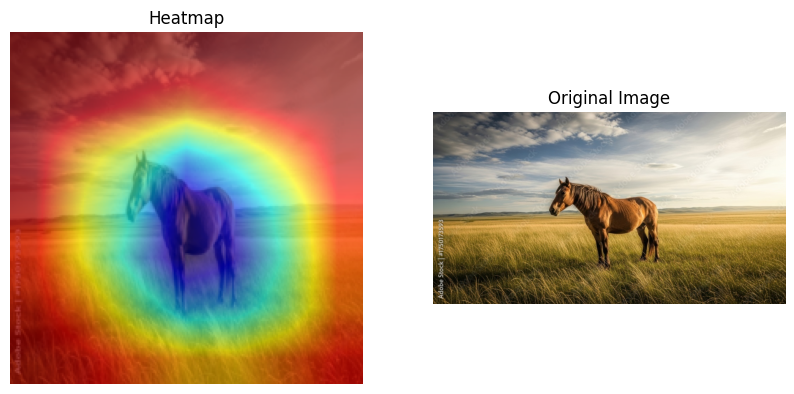

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(overlay)
axes[0].set_title("Heatmap")
axes[0].axis('off')
axes[1].imshow(image)
axes[1].set_title("Original Image")
axes[1].axis('off')
plt.show()